#  Data science

## Preliminary analysis:

### Importing libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.preprocessing import MinMaxScaler

### Import the datasets into the Python environment

In [ ]:
items = pd.read_csv("/content/items.csv")
rest = pd.read_csv("/content/resturants.csv")
sale = pd.read_csv("/content/sales.csv")

#### dataset's shape

In [ ]:
items.shape

(100, 5)

In [ ]:
rest.shape

(6, 2)

In [ ]:
sale.shape

(109600, 4)

#### dataset's look

In [ ]:
items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [ ]:
rest.head()

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe


In [ ]:
sale.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


#### dataset's structure

In [ ]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [ ]:
rest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 224.0+ bytes


In [ ]:
sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   price       109600 non-null  float64
 3   item_count  109600 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.3+ MB


### Merge the datasets into a single dataset that includes the date, item id, price, item count, item names, kcal values, store id, and store name

#### Hidden task
- Renaming of columns

In [ ]:
# Rename a column if needed
rest.rename(columns={'id': 'store_id'}, inplace=True)
items.rename(columns={'name': 'itme_name'}, inplace=True)
items.rename(columns={'id': 'item_id'}, inplace=True)

In [ ]:
# Merging datasets (if you have another dataset, use pd.merge())
df1 = pd.merge(items, rest, on='store_id')
df = pd.merge(df1,sale, on = "item_id")

In [ ]:
df

,item_id,store_id,itme_name,kcal,cost,name,date,price,item_count
0,1,4,Chocolate Cake,554,6.71,Fou Cher,2019-01-01,6.71,0.0
1,1,4,Chocolate Cake,554,6.71,Fou Cher,2019-01-02,6.71,0.0
2,1,4,Chocolate Cake,554,6.71,Fou Cher,2019-01-03,6.71,0.0
3,1,4,Chocolate Cake,554,6.71,Fou Cher,2019-01-04,6.71,0.0
4,1,4,Chocolate Cake,554,6.71,Fou Cher,2019-01-05,6.71,0.0
...,...,...,...,...,...,...,...,...,...
109595,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-12-27,2.48,0.0
109596,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-12-28,2.48,0.0
109597,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-12-29,2.48,0.0
109598,100,2,Awesome Vodka Cocktail,223,2.48,Beachfront Bar,2021-12-30,2.48,0.0


In [ ]:
# Save modified DataFrame to Excel
df.to_csv('df.csv', index=False)

## Exploratory data analysis :

### Examine the overall date wise sales to understand the pattern

#### Add sales column to df

In [ ]:
df.columns

Index(['item_id', 'store_id', 'itme_name', 'kcal', 'cost', 'name', 'date',
       'price', 'item_count'],
      dtype='object')

In [ ]:
# Adding a 'total_sale' column by multiplying 'price' and 'item_count'
df['total_sale'] = df['price'] * df['item_count']

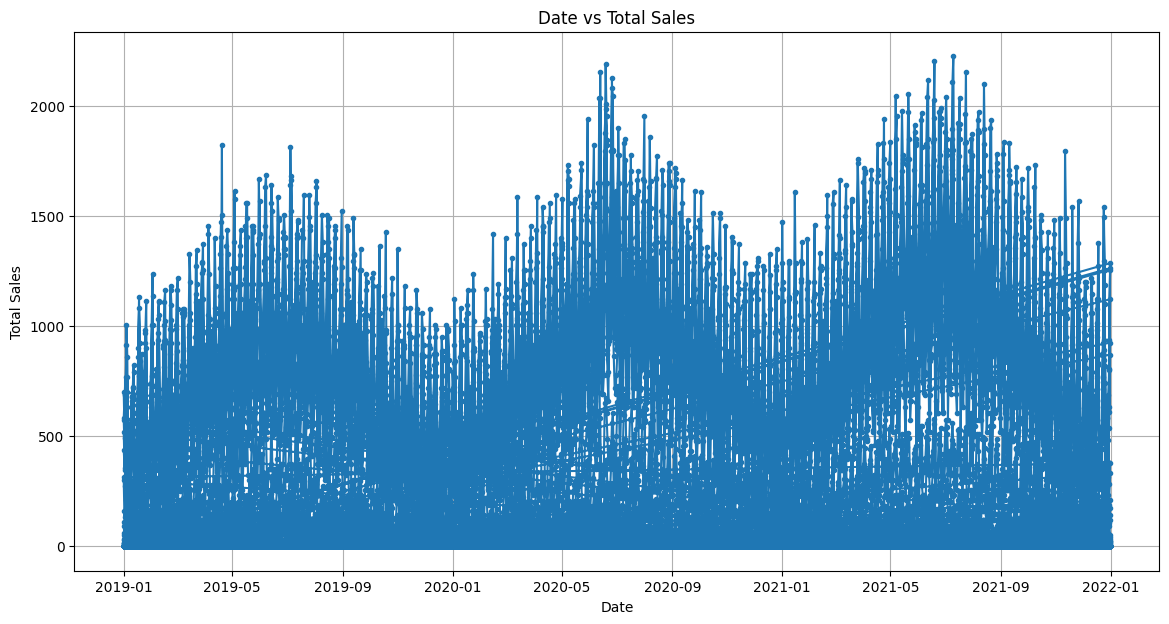

In [ ]:
import matplotlib.pyplot as plt

# Check if 'date' column is in datetime format; convert if necessary
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Plotting Date vs Total Sales
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['total_sale'], marker='o', linestyle='-', markersize=3)
plt.title("Date vs Total Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


### Find out how sales fluctuate across different days of the week

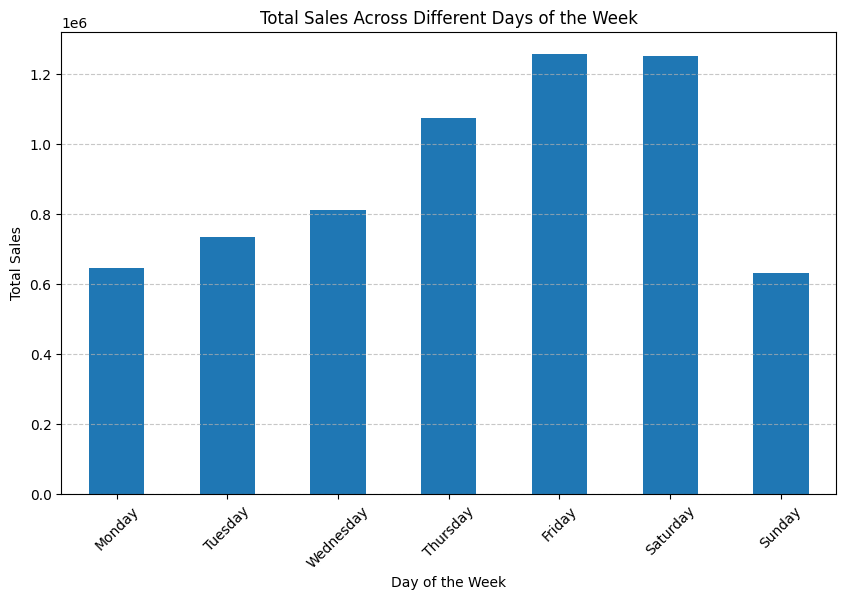

In [ ]:
import matplotlib.pyplot as plt

# Ensure 'date' is in datetime format to extract day of the week
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Extract the day of the week and calculate total sales for each day
df['day_of_week'] = df['date'].dt.day_name()
weekday_sales = df.groupby('day_of_week')['total_sale'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

# Plotting total sales across different days of the week
plt.figure(figsize=(10, 6))
weekday_sales.plot(kind='bar')
plt.title("Total Sales Across Different Days of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Look for any noticeable trends in the sales data for different months of the year

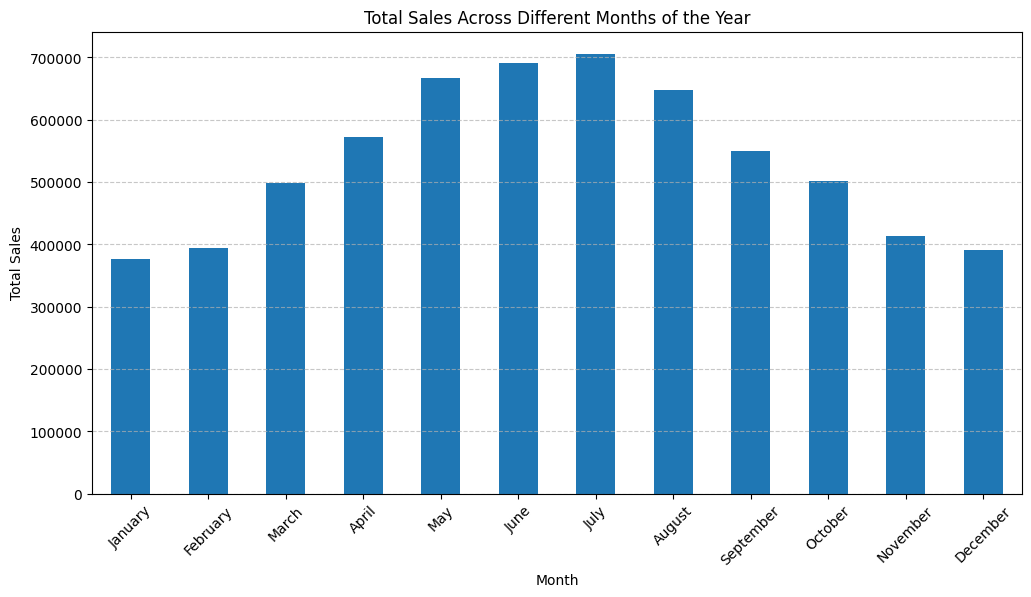

In [ ]:
import matplotlib.pyplot as plt

# Ensure 'date' is in datetime format to extract month information
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Extract month and calculate total sales for each month
df['month'] = df['date'].dt.month_name()
monthly_sales = df.groupby('month')['total_sale'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# Plotting total sales across different months
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='bar')
plt.title("Total Sales Across Different Months of the Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Examine the sales distribution across different quarters averaged over the years. Identify any noticeable patterns.

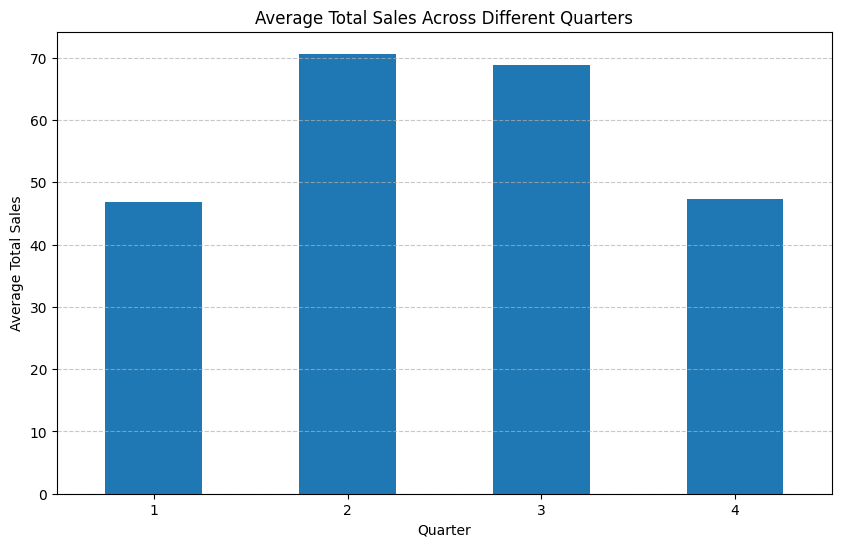

In [ ]:
import matplotlib.pyplot as plt

# Ensure 'date' is in datetime format to extract quarter information
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Extract the quarter and calculate average total sales for each quarter
df['quarter'] = df['date'].dt.quarter
quarterly_sales = df.groupby('quarter')['total_sale'].mean()

# Plotting the average total sales across different quarters
plt.figure(figsize=(10, 6))
quarterly_sales.plot(kind='bar')
plt.title("Average Total Sales Across Different Quarters")
plt.xlabel("Quarter")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.

In [ ]:
# Ensure 'date' is in datetime format to extract year, month, and day information
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Extract year, month, and day from 'date'
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day_name()

# Calculate total sales for each store_id
store_sales_total = df.groupby('store_id')['total_sale'].sum()

# Find the store_id with the highest total sales
top_store_id = store_sales_total.idxmax()
top_store_sales = store_sales_total.max()

# Calculate total sales for each store_id across different years, months, and days
yearly_sales = df.groupby(['store_id', 'year'])['total_sale'].sum()
monthly_sales = df.groupby(['store_id', 'month'])['total_sale'].sum()
daily_sales = df.groupby(['store_id', 'day'])['total_sale'].sum()


In [ ]:
import pandas as pd

# Ensure 'date' is in datetime format to extract year, month, and day information
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Extract year, month, and day from 'date'
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name()
df['day'] = df['date'].dt.day_name()

# Calculate total sales for each store_id
store_sales_total = df.groupby('store_id')['total_sale'].sum()

# Find the store_id with the highest total sales
top_store_id = store_sales_total.idxmax()
top_store_sales = store_sales_total.max()

# Calculate total sales for each store_id across different years, months, and days
yearly_sales = df.groupby(['store_id', 'year'])['total_sale'].sum()
monthly_sales = df.groupby(['store_id', 'month'])['total_sale'].sum()
daily_sales = df.groupby(['store_id', 'day'])['total_sale'].sum()

# Display results
print("Total Sales per Store:\n", store_sales_total)
print("\nTop Store ID:", top_store_id, "with Total Sales:", top_store_sales)
print("\nYearly Sales by Store:\n", yearly_sales)
print("\nMonthly Sales by Store:\n", monthly_sales)
print("\nDaily Sales by Store:\n", daily_sales)


Total Sales per Store:
 store_id
1    6337275.69
2       3796.20
3       2578.27
4      27885.37
5      16551.43
6      15651.49
Name: total_sale, dtype: float64

Top Store ID: 1 with Total Sales: 6337275.69

Yearly Sales by Store:
 store_id  year
1         2019    1849483.49
          2020    2112331.91
          2021    2375460.29
2         2019       1281.85
          2020       1267.21
          2021       1247.14
3         2019        872.59
          2020        828.65
          2021        877.03
4         2019       9698.80
          2020       8590.87
          2021       9595.70
5         2019       5292.93
          2020       5347.71
          2021       5910.79
6         2019       5132.65
          2020       5314.43
          2021       5204.41
Name: total_sale, dtype: float64

Monthly Sales by Store:
 store_id  month    
1         April        565964.33
          August       641471.70
          December     385124.24
          February     389551.18
          January  

# Machine learning

### Identify the most popular items overall and the stores where they are being sold. Also, find out the most popular item at each store

In [ ]:
# Identify the most popular items overall by summing item_count for each item_name
overall_popular_items = df.groupby('itme_name')['item_count'].sum().sort_values(ascending=False)

# Identify the store_id(s) where each item_name is being sold
items_stores = df.groupby('itme_name')['store_id'].unique()

# Combine popular items with their stores
popular_items_with_stores = pd.DataFrame({'Total Item Count': overall_popular_items, 'Store IDs': items_stores})

# Identify the most popular item at each store by item_count
popular_item_per_store = df.groupby(['store_id', 'itme_name'])['item_count'].sum()
most_popular_item_per_store = popular_item_per_store.groupby('store_id').idxmax().apply(lambda x: x[1])

# Display results
print("Most Popular Items Overall with Store IDs:")
print(popular_items_with_stores)
print("\nMost Popular Item at Each Store:")
print(most_popular_item_per_store)


Most Popular Items Overall with Store IDs:
                                    Total Item Count Store IDs
itme_name                                                     
Amazing Cocktail                                91.0       [6]
Amazing Fish with Vegetables Meal            13190.0       [1]
Amazing Frozen Milky Cake                      211.0       [1]
Amazing Lamb Dinner                             52.0       [4]
Amazing Steak Dinner with Rolls              34439.0       [1]
...                                              ...       ...
Sweet Fruity Cake                             2946.0       [1]
Sweet Lamb Cake                              18764.0       [1]
Sweet Savory Cake                               25.0       [4]
Sweet Vegi Soft Drink                           19.0       [2]
Vegetarian Plate with Bread entree              24.0       [4]

[94 rows x 2 columns]

Most Popular Item at Each Store:
store_id
1               Strawberry Smoothy
2          Fantastic Milky Smoothy
3 

### Determine if the store with the highest sales volume is also making the most money per day

In [ ]:
# Ensure 'date' is in datetime format to aggregate sales per day
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

# Calculate total item_count per store
store_total_item_count = df.groupby('store_id')['item_count'].sum()

# Identify the store_id with the highest item_count
top_item_store_id = store_total_item_count.idxmax()

# Calculate total sales per day for each store_id
daily_sales_per_store = df.groupby(['date', 'store_id'])['total_sale'].sum().reset_index()

# Calculate average daily sales for each store
average_daily_sales_per_store = daily_sales_per_store.groupby('store_id')['total_sale'].mean()

# Compare if the store with highest item_count has the highest total sale per day
top_sales_store_id = average_daily_sales_per_store.idxmax()
top_sales_store_avg = average_daily_sales_per_store.max()

# Display the results
result = {
    "Top Store by Item Count": top_item_store_id,
    "Top Store by Average Daily Sales": top_sales_store_id,
    "Highest Average Daily Sales Amount": top_sales_store_avg,
}

result


{'Top Store by Item Count': 1,
 'Top Store by Average Daily Sales': 1,
 'Highest Average Daily Sales Amount': 5782.185848540146}

### Identify the most expensive item at each restaurant and find out its calorie count

In [ ]:
# Identify the most expensive item_name at each store by using the 'price' column
most_expensive_item_per_store = df.loc[df.groupby('store_id')['price'].idxmax(), ['store_id', 'itme_name', 'price', 'kcal']]

# Rename columns for clarity in output
most_expensive_item_per_store.columns = ['Store ID', 'Most Expensive Item', 'Price', 'Calorie Count']

# Display the result
most_expensive_item_per_store


,Store ID,Most Expensive Item,Price,Calorie Count
2192,1,Sweet Fruity Cake,29.22,931
66856,2,Sweet Vegi Soft Drink,5.70,538
83296,3,Blue Ribbon Frozen Milky Cake,7.70,636
86584,4,Blue Ribbon Fruity Vegi Lunch,53.98,881
53704,5,Pike Lunch,26.37,653
28496,6,Steak Meal,26.21,607


## Forecasting using machine learning algorithms:

### Build and compare linear regression, random forest, and XGBoost models for predictions

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Ensure 'date' is in datetime format
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    df['date'] = pd.to_datetime(df['date'])

#### Generate necessary features for the development of these models, like day of the week, quarter of the year, month, year, day of the month and so on

In [ ]:
# Generate necessary features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['day_of_month'] = df['date'].dt.day
df['quarter'] = df['date'].dt.quarter

In [ ]:
# Ensure 'total_sale' is calculated as 'price' * 'item_count'
df['total_sale'] = df['price'] * df['item_count']
features = ['year', 'month', 'day_of_week', 'day_of_month', 'quarter', 'item_count']
X = df[features]
y = df['total_sale']

#### Use the data from the last six months as the testing data

In [ ]:
# Splitting the data: last six months as testing data
cutoff_date = df['date'].max() - pd.DateOffset(months=6)
X_train, X_test = X[df['date'] < cutoff_date], X[df['date'] >= cutoff_date]
y_train, y_test = y[df['date'] < cutoff_date], y[df['date'] >= cutoff_date]

In [ ]:
# Initialize models
lr_model = LinearRegression()
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

In [ ]:
# Fit the models
lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

#### Compute the root mean square error (RMSE) values for each model to compare their performances

In [ ]:
# Predictions and RMSE calculations
lr_predictions = lr_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

In [ ]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

In [ ]:
# Model performance summary
model_performance = {
    'Linear Regression RMSE': lr_rmse,
    'Random Forest RMSE': rf_rmse,
    'XGBoost RMSE': xgb_rmse
}


In [ ]:
# Select best model based on RMSE
model_dict = {
    'Linear Regression RMSE': lr_model,
    'Random Forest RMSE': rf_model,
    'XGBoost RMSE': xgb_model
}
best_model_name = min(model_performance, key=model_performance.get)
best_model = model_dict[best_model_name]

# Displaying the best model name and performance
print(f"Best Model: {best_model_name} with RMSE of {model_performance[best_model_name]}")


Best Model: Random Forest RMSE with RMSE of 96.14193102973127


In [ ]:
# Forecast for the next year using the best model
future_dates = pd.date_range(start=df['date'].max() + pd.DateOffset(days=1), periods=365, freq='D')
future_df = pd.DataFrame({
    'year': future_dates.year,
    'month': future_dates.month,
    'day_of_week': future_dates.dayofweek,
    'day_of_month': future_dates.day,
    'quarter': future_dates.quarter,
    'item_count': 0  # Assuming 0 for simplicity, this can be adjusted as needed
})


In [ ]:
# Generate forecast
future_forecast = best_model.predict(future_df)

#### Use the best-performing models to make a forecast for the next year

In [ ]:
# Display the results
print("Model Performance (RMSE):", model_performance)
print(f"Best Model: {best_model_name}")
print("Sample of Next Year's Forecasted Sales:", future_forecast[:5])

Model Performance (RMSE): {'Linear Regression RMSE': 173.6693166232147, 'Random Forest RMSE': 96.14193102973127, 'XGBoost RMSE': 102.37006784739485}
Best Model: Random Forest RMSE
Sample of Next Year's Forecasted Sales: [0. 0. 0. 0. 0.]


# Deep learning

## Forecasting using deep learning algorithms:

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Ensure 'date' is in datetime format
df['date'] = pd.to_datetime(df['date'])
# Sort the data by date to maintain time order
df = df.sort_values('date')

In [ ]:
# Use 'total_sale' as the prediction target
df['total_sale'] = df['price'] * df['item_count']

In [ ]:
# Scaling the data
scaler = MinMaxScaler()
df['total_sale_scaled'] = scaler.fit_transform(df[['total_sale']])

In [ ]:
# Define the series for LSTM
data = df['total_sale_scaled'].values

In [ ]:
# Splitting the data: Last 12 months for testing
train_size = len(data) - 365  # Assuming daily data for the last year as test set
train, test = data[:train_size], data[train_size:]

In [ ]:
# Define the TimeSeriesGenerator for LSTM model
sequence_length = 30  # Sequence length (30 days lookback)
batch_size = 1
train_generator = TimeseriesGenerator(train, train, length=sequence_length, batch_size=batch_size)
test_generator = TimeseriesGenerator(test, test, length=sequence_length, batch_size=batch_size)

In [ ]:
# Build LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(sequence_length, 1)),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.fit(train_generator, epochs=2, verbose=1)  # Use epochs=2, not epochs=02


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
    13/109205 ━━━━━━━━━━━━━━━━━━━━ 16:53 9ms/step - loss: 7.8199e-05

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


109205/109205 ━━━━━━━━━━━━━━━━━━━━ 1177s 11ms/step - loss: 0.0094
Epoch 2/2
109205/109205 ━━━━━━━━━━━━━━━━━━━━ 1192s 11ms/step - loss: 0.0094


In [ ]:
# Predictions for test data
predictions = model.predict(test_generator)
predictions = scaler.inverse_transform(predictions)  # Inverse scaling to get actual sales values
test_actual = scaler.inverse_transform(test[sequence_length:].reshape(-1, 1))  # Actual sales values

335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# Calculate MAPE
mape = mean_absolute_percentage_error(test_actual, predictions)

In [ ]:
# Train on entire series for 3-month forecast
full_generator = TimeseriesGenerator(data, data, length=sequence_length, batch_size=batch_size)
model.fit(full_generator, epochs=2, verbose=1)

Epoch 1/2
100318/109570 ━━━━━━━━━━━━━━━━━━━━ 1:41 11ms/step - loss: 0.0095

In [ ]:
# Forecast for the next 3 months (90 days)
forecast = []
input_seq = data[-sequence_length:]

for _ in range(90):
    input_seq = input_seq.reshape((1, sequence_length, 1))
    next_pred = model.predict(input_seq)[0][0]
    forecast.append(next_pred)
    input_seq = np.append(input_seq[0][1:], [[next_pred]], axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


In [ ]:
# Inverse transform forecasted values
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))

In [ ]:
# Display MAPE and forecast
print("Mean Absolute Percentage Error (MAPE):", mape)
print("Forecast for the next 3 months (first 5 days shown):", forecast[:5])

Mean Absolute Percentage Error (MAPE): 1.861115537872255e+17
Forecast for the next 3 months (first 5 days shown): [[55.311268]
 [55.311268]
 [55.311268]
 [55.311268]
 [55.311268]]
